**Splits**

In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import config
from src.data import loader, preprocessing
from src.data.augmentation import build_augmentation
from src.models.cnn import build_custom_cnn

train_df, val_df, test_df = loader.create_splits()
print("Train:", len(train_df), "| Validation:", len(val_df), "| Test:", len(test_df))
pd.DataFrame({"train": train_df["class"].value_counts(),
              "validation": val_df["class"].value_counts(),
              "test": test_df["class"].value_counts()})

Train: 4214 | Validation: 1054 | Test: 1600


,train,validation,test
class,,,
glioma,1116,280,400
meningioma,1029,258,400
notumor,979,244,400
pituitary,1090,272,400


**Pipeline**

In [6]:
train_ds = preprocessing.make_dataset(train_df, training=True)
images, labels = next(iter(train_ds))
print("Batch of images:", images.shape, images.dtype)
print("Pixel range:", float(images.numpy().min()), "to", float(images.numpy().max()))
print("First labels:", labels.numpy()[:10])

Batch of images: (32, 224, 224, 3) <dtype: 'float32'>
Pixel range: 0.0 to 255.00006103515625
First labels: [2 1 2 0 3 3 0 0 2 3]


**Augmentation preview**

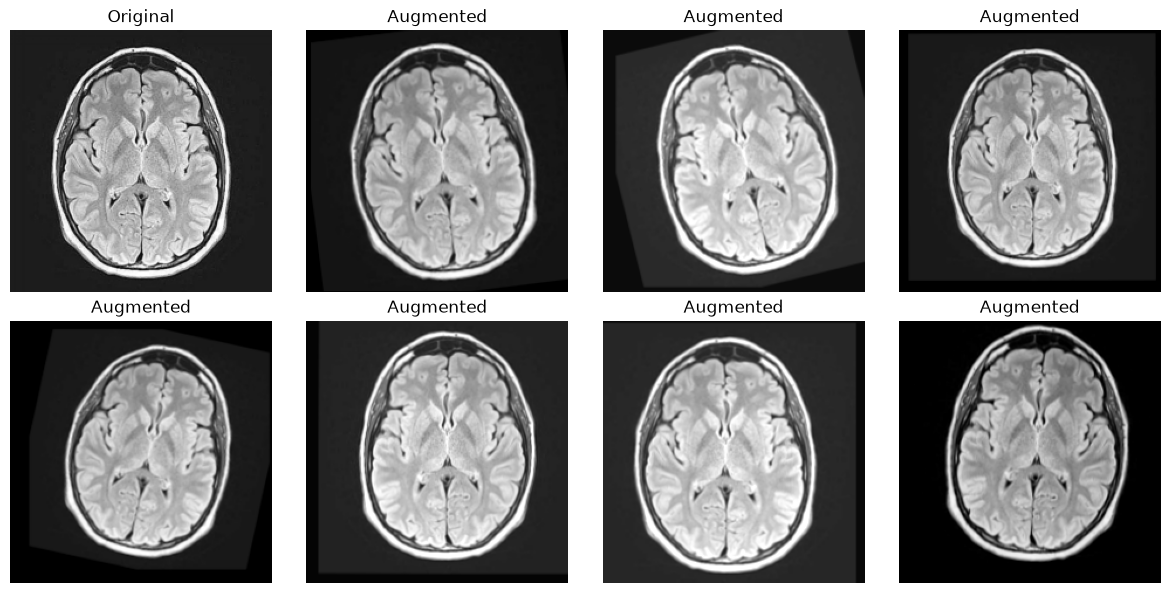

In [7]:
augment = build_augmentation()
one_image = images[:1]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(one_image[0].numpy().astype("uint8"))
axes[0, 0].set_title("Original")
for ax in list(axes.flat)[1:]:
    changed = augment(one_image, training=True)[0].numpy()
    ax.imshow(np.clip(changed, 0, 255).astype("uint8"))
    ax.set_title("Augmented")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "augmentation_examples.png", dpi=150)
plt.show()

**Model**

In [8]:
model = build_custom_cnn()
model.summary()
print(model.predict(images[:4], verbose=0).round(3))

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

[[0.245 0.25  0.254 0.251]
 [0.247 0.25  0.252 0.25 ]
 [0.247 0.249 0.254 0.25 ]
 [0.248 0.25  0.252 0.25 ]]
